<a href="https://colab.research.google.com/github/Ezhreal/FormationIA/blob/incourse/exercicios/RegressaoStatsModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
# ===== IMPORTAÇÕES =====
# Bibliotecas básicas para análise de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas estatísticas
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.regressionplots import plot_ccpr
from mpl_toolkits.mplot3d import Axes3D

# Configurações de visualização
sns.set_theme()
%matplotlib inline

# Carregar o conjunto de dados (usando o dataset mtcars como exemplo)
# Se você tiver seu próprio dataset, substitua esta linha
base = pd.read_csv('mt_cars.csv')

# Verificando as primeiras linhas do dataset
base.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [43]:
# Verificar informações básicas do dataset
print("Dimensões do dataset:", base.shape)
print("\nInformações sobre as colunas:")
base.info()

print("\nEstatísticas descritivas:")
base.describe()

# Verificar se há valores ausentes
print("\nValores ausentes por coluna:")
print(base.isnull().sum())

# Remover colunas desnecessárias se existirem (como índices duplicados)
if 'Unnamed: 0' in base.columns:
    base = base.drop(['Unnamed: 0'], axis=1)
    print("\nColuna 'Unnamed: 0' removida.")

Dimensões do dataset: (32, 12)

Informações sobre as colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  32 non-null     object 
 1   mpg         32 non-null     float64
 2   cyl         32 non-null     int64  
 3   disp        32 non-null     float64
 4   hp          32 non-null     int64  
 5   drat        32 non-null     float64
 6   wt          32 non-null     float64
 7   qsec        32 non-null     float64
 8   vs          32 non-null     int64  
 9   am          32 non-null     int64  
 10  gear        32 non-null     int64  
 11  carb        32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB

Estatísticas descritivas:

Valores ausentes por coluna:
Unnamed: 0    0
mpg           0
cyl           0
disp          0
hp            0
drat          0
wt            0
qsec          0
vs            

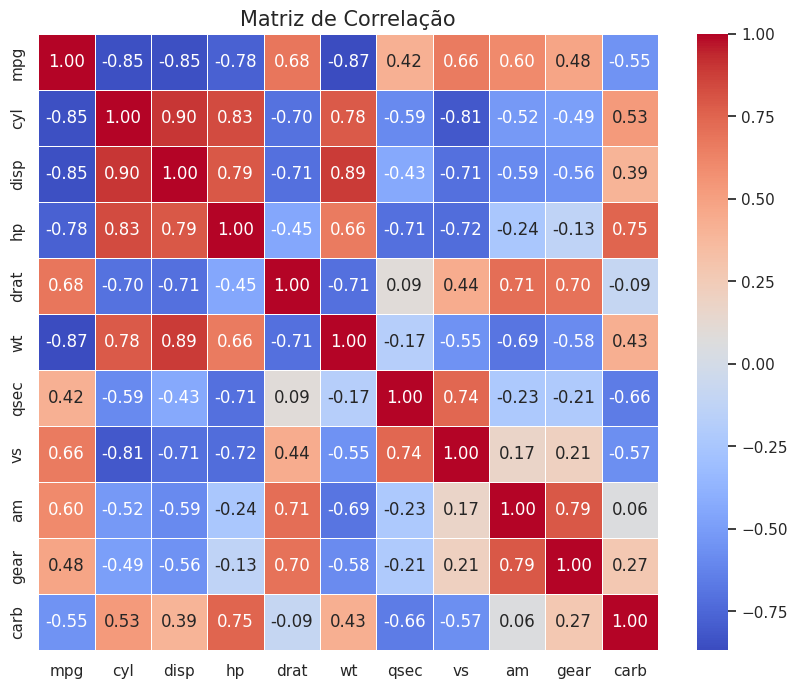

Correlações com 'mpg' (em ordem decrescente):
mpg     1.000000
drat    0.681172
vs      0.664039
am      0.599832
gear    0.480285
qsec    0.418684
carb   -0.550925
hp     -0.776168
disp   -0.847551
cyl    -0.852162
wt     -0.867659
Name: mpg, dtype: float64


In [30]:
# Calcular a matriz de correlação
corr = base.corr()

# Visualizar a matriz de correlação como um heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=15)
plt.show()

# Explicação das correlações com mpg (nossa variável alvo)
correlacoes_mpg = corr['mpg'].sort_values(ascending=False)
print("Correlações com 'mpg' (em ordem decrescente):")
print(correlacoes_mpg)

<Axes: >

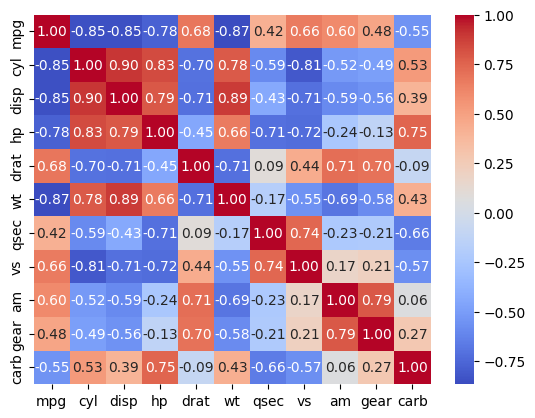

In [16]:

# Calcula a matriz de correlação para todas as colunas numéricas do DataFrame
corr = base.corr()

# Cria um mapa de calor (heatmap) para visualizar a matriz de correlação
# cmap='coolwarm': Define o esquema de cores (azul para correlações negativas, vermelho para positivas)
# annot=True: Mostra os valores numéricos em cada célula
# fmt='.2f': Formata os valores para mostrar apenas 2 casas decimais
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')

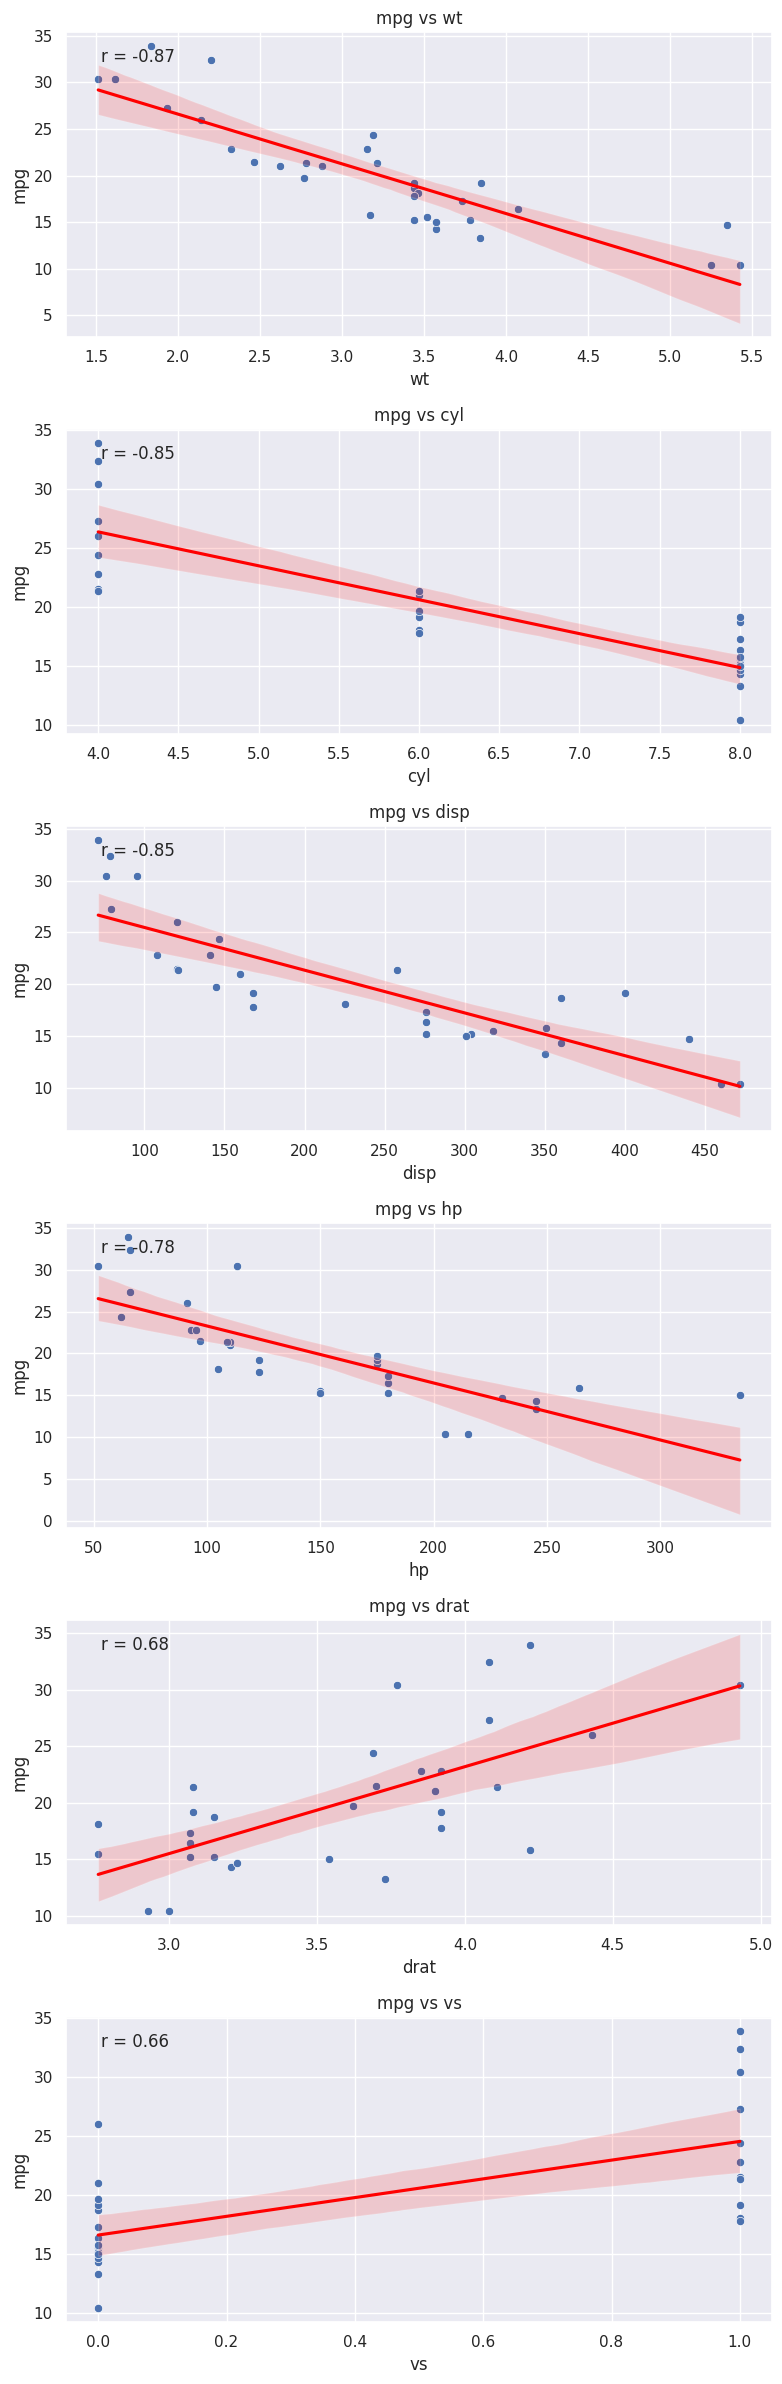

In [31]:
# Selecionar as variáveis mais correlacionadas com mpg
column_pairs = [('mpg', 'wt'), ('mpg', 'cyl'), ('mpg', 'disp'),
                ('mpg', 'hp'), ('mpg', 'drat'), ('mpg', 'vs')]

n_plots = len(column_pairs)
fig, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(8, 4*n_plots))

# Criar gráficos de dispersão para cada par de variáveis
for i, pair in enumerate(column_pairs):
    y_col, x_col = pair  # Invertendo para mpg ficar no eixo y
    sns.scatterplot(x=x_col, y=y_col, data=base, ax=axes[i])

    # Adicionar linha de tendência
    sns.regplot(x=x_col, y=y_col, data=base, ax=axes[i],
                scatter=False, line_kws={"color": "red"})

    # Adicionar o valor de correlação no gráfico
    corr_val = base[x_col].corr(base[y_col])
    axes[i].annotate(f'r = {corr_val:.2f}',
                    xy=(0.05, 0.95), xycoords='axes fraction',
                    fontsize=12, ha='left', va='top')

    axes[i].set_title(f'{y_col} vs {x_col}', fontsize=12)

plt.tight_layout()
plt.show()

In [37]:
# Construindo um modelo de regressão linear múltipla
# Incluímos as variáveis com maiores correlações com mpg
modelo = smf.ols(formula='mpg ~ wt + disp + hp', data=base)
modelo = modelo.fit()

# Exibir o sumário do modelo com estatísticas detalhadas
print(modelo.summary())

# Explicação dos principais componentes do resultado:
print("\n--- INTERPRETAÇÃO DOS RESULTADOS ---")
print("\n1. Coeficientes:")
print(f"- Intercepto: {modelo.params[0]:.4f}")
print(f"- Peso (wt): {modelo.params[1]:.4f} - Para cada unidade de aumento no peso, mpg muda em {modelo.params[1]:.4f} unidades, mantendo outras variáveis constantes")
print(f"- Deslocamento (disp): {modelo.params[2]:.4f} - Para cada unidade de aumento no deslocamento, mpg muda em {modelo.params[2]:.4f} unidades, mantendo outras variáveis constantes")
print(f"- Potência (hp): {modelo.params[3]:.4f} - Para cada unidade de aumento na potência, mpg muda em {modelo.params[3]:.4f} unidades, mantendo outras variáveis constantes")

print("\n2. Significância estatística (valor p):")
for i, var in enumerate(['Intercepto', 'wt', 'disp', 'hp']):
    print(f"- {var}: {modelo.pvalues[i]:.4f} {'(significativo)' if modelo.pvalues[i] < 0.05 else '(não significativo)'}")

print("\n3. Qualidade do modelo:")
print(f"- R² (coeficiente de determinação): {modelo.rsquared:.4f} - O modelo explica {modelo.rsquared*100:.1f}% da variância em mpg")
print(f"- R² ajustado: {modelo.rsquared_adj:.4f} - Ajustado pelo número de variáveis")
print(f"- Estatística F: {modelo.fvalue:.4f} com valor p: {modelo.f_pvalue:.4e} - Testa se o modelo como um todo é significativo")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.808
Method:                 Least Squares   F-statistic:                     44.57
Date:                Fri, 25 Apr 2025   Prob (F-statistic):           8.65e-11
Time:                        19:50:15   Log-Likelihood:                -74.321
No. Observations:                  32   AIC:                             156.6
Df Residuals:                      28   BIC:                             162.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     37.1055      2.111     17.579      0.0

<ipython-input-37-7ef888a8bfe3>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"- Intercepto: {modelo.params[0]:.4f}")
<ipython-input-37-7ef888a8bfe3>:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"- Peso (wt): {modelo.params[1]:.4f} - Para cada unidade de aumento no peso, mpg muda em {modelo.params[1]:.4f} unidades, mantendo outras variáveis constantes")
<ipython-input-37-7ef888a8bfe3>:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by positio

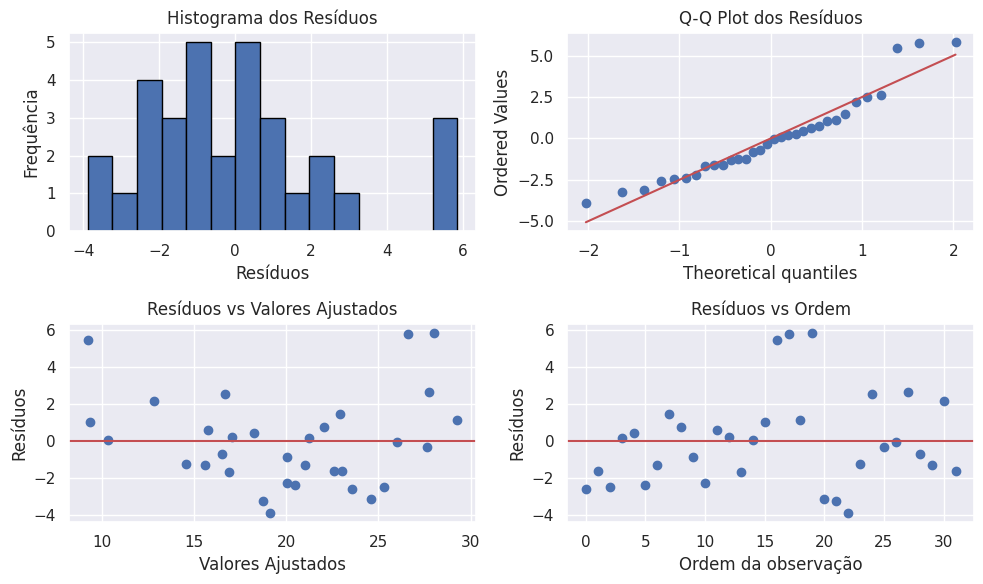

Teste de Shapiro-Wilk para normalidade dos resíduos:
Estatística: 0.9273, Valor p: 0.0330
Conclusão: Os resíduos não seguem uma distribuição normal (p < 0.05)

Teste de Breusch-Pagan para heteroscedasticidade:
Estatística: 0.9459, Valor p: 0.8143
Conclusão: Os resíduos não apresentam heteroscedasticidade (p > 0.05)

Teste de Durbin-Watson para autocorrelação:
Estatística: 1.3673
Valores próximos a 2 indicam ausência de autocorrelação.
Valores próximos a 0 indicam autocorrelação positiva.
Valores próximos a 4 indicam autocorrelação negativa.


In [38]:
# Obter os resíduos (diferenças entre valores observados e previstos)
residuos = modelo.resid

# 1. Histograma dos resíduos
plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.hist(residuos, bins=15, edgecolor='black')
plt.title('Histograma dos Resíduos')
plt.xlabel('Resíduos')
plt.ylabel('Frequência')

# 2. Q-Q plot para verificar normalidade
plt.subplot(2, 2, 2)
stats.probplot(residuos, dist='norm', plot=plt)
plt.title('Q-Q Plot dos Resíduos')

# 3. Resíduos vs Valores ajustados (fitted values)
plt.subplot(2, 2, 3)
plt.scatter(modelo.fittedvalues, residuos)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Resíduos vs Valores Ajustados')
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')

# 4. Resíduos vs Ordem de observação
plt.subplot(2, 2, 4)
plt.scatter(range(len(residuos)), residuos)
plt.axhline(y=0, color='r', linestyle='-')
plt.title('Resíduos vs Ordem')
plt.xlabel('Ordem da observação')
plt.ylabel('Resíduos')

plt.tight_layout()
plt.show()

# Testes estatísticos para os pressupostos da regressão
# 1. Teste de normalidade dos resíduos (Shapiro-Wilk)
stat, pval = stats.shapiro(residuos)
print("Teste de Shapiro-Wilk para normalidade dos resíduos:")
print(f"Estatística: {stat:.4f}, Valor p: {pval:.4f}")
print(f"Conclusão: Os resíduos {'não ' if pval < 0.05 else ''}seguem uma distribuição normal (p {'<' if pval < 0.05 else '>'} 0.05)\n")

# 2. Teste de heteroscedasticidade (Breusch-Pagan)
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(residuos, modelo.model.exog)
print("Teste de Breusch-Pagan para heteroscedasticidade:")
print(f"Estatística: {bp_test[0]:.4f}, Valor p: {bp_test[1]:.4f}")
print(f"Conclusão: Os resíduos {'apresentam' if bp_test[1] < 0.05 else 'não apresentam'} heteroscedasticidade (p {'<' if bp_test[1] < 0.05 else '>'} 0.05)\n")

# 3. Teste de autocorrelação (Durbin-Watson)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuos)
print("Teste de Durbin-Watson para autocorrelação:")
print(f"Estatística: {dw:.4f}")
print("Valores próximos a 2 indicam ausência de autocorrelação.")
print("Valores próximos a 0 indicam autocorrelação positiva.")
print("Valores próximos a 4 indicam autocorrelação negativa.")

In [39]:
# Calcular correlações entre as variáveis independentes
predictors = ['wt', 'disp', 'hp']
correlation_matrix = base[predictors].corr()

print("Matriz de correlação entre variáveis independentes:")
print(correlation_matrix)
print("\nPreocupações com multicolinearidade:")
for i in range(len(predictors)):
    for j in range(i+1, len(predictors)):
        corr_value = correlation_matrix.iloc[i, j]
        var1, var2 = predictors[i], predictors[j]
        print(f"- Correlação entre {var1} e {var2}: {corr_value:.4f}", end=" ")
        if abs(corr_value) > 0.7:
            print("(ALTA - pode causar multicolinearidade)")
        else:
            print("(Aceitável)")

# Calcular o VIF (Variance Inflation Factor)
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Preparar os dados
X = base[predictors]
X = sm.add_constant(X)  # Adicionar constante para o intercepto

# Calcular VIF para cada variável
print("\nFatores de Inflação de Variância (VIF):")
for i in range(1, X.shape[1]):  # Começar de 1 para pular a constante
    vif = variance_inflation_factor(X.values, i)
    print(f"- {X.columns[i]}: {vif:.4f}", end=" ")
    if vif > 10:
        print("(MUITO ALTO - problemático)")
    elif vif > 5:
        print("(ALTO - preocupante)")
    else:
        print("(Aceitável)")

Matriz de correlação entre variáveis independentes:
            wt      disp        hp
wt    1.000000  0.887980  0.658748
disp  0.887980  1.000000  0.790949
hp    0.658748  0.790949  1.000000

Preocupações com multicolinearidade:
- Correlação entre wt e disp: 0.8880 (ALTA - pode causar multicolinearidade)
- Correlação entre wt e hp: 0.6587 (Aceitável)
- Correlação entre disp e hp: 0.7909 (ALTA - pode causar multicolinearidade)

Fatores de Inflação de Variância (VIF):
- wt: 4.8446 (Aceitável)
- disp: 7.3245 (ALTO - preocupante)
- hp: 2.7366 (Aceitável)


Comparação de modelos:
                       R²  R² Ajustado         AIC         BIC      RMSE
Modelo Completo  0.826836     0.808283  156.642973  162.505916  2.468493
Modelo wt        0.752833     0.744594  164.029429  166.960901  2.949163
Modelo wt+hp     0.826785     0.814840  154.652339  159.049547  2.468854
Modelo disp+hp   0.748240     0.730877  166.618564  171.015772  2.976436

Resumo do modelo final selecionado:
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     69.21
Date:                Fri, 25 Apr 2025   Prob (F-statistic):           9.11e-12
Time:                        20:32:02   Log-Likelihood:                -74.326
No. Observations:                  32   AIC:                             154.7
Df Residuals:         

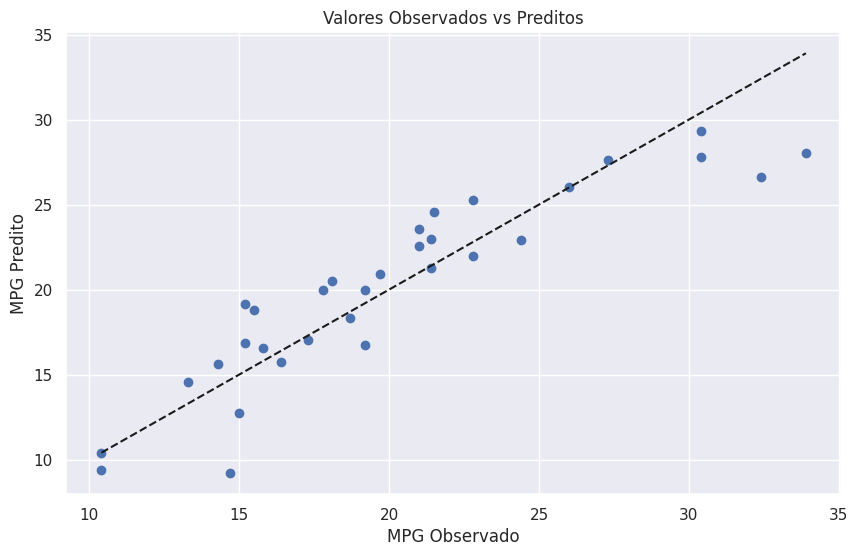


Métricas de erro do modelo final:
- Erro Absoluto Médio (MAE): 1.9015
- Erro Quadrático Médio (MSE): 6.0952
- Raiz do Erro Quadrático Médio (RMSE): 2.4689


In [44]:
# Baseado na análise anterior, vamos criar e comparar diferentes modelos
# Definir os modelos a serem comparados
modelos = {
    'Modelo Completo': smf.ols(formula='mpg ~ wt + disp + hp', data=base).fit(),
    'Modelo wt': smf.ols(formula='mpg ~ wt', data=base).fit(),
    'Modelo wt+hp': smf.ols(formula='mpg ~ wt + hp', data=base).fit(),
    'Modelo disp+hp': smf.ols(formula='mpg ~ disp + hp', data=base).fit()
}

# Criar tabela comparativa de métricas
resultados = pd.DataFrame({
    'R²': [modelo.rsquared for modelo in modelos.values()],
    'R² Ajustado': [modelo.rsquared_adj for modelo in modelos.values()],
    'AIC': [modelo.aic for modelo in modelos.values()],
    'BIC': [modelo.bic for modelo in modelos.values()],
    'RMSE': [np.sqrt(np.mean(modelo.resid**2)) for modelo in modelos.values()]
})

resultados.index = modelos.keys()
print("Comparação de modelos:")
print(resultados)

# Baseado nos resultados, selecionar o melhor modelo
# Suponhamos que o modelo 'wt+hp' seja o melhor
modelo_final = modelos['Modelo wt+hp']
print("\nResumo do modelo final selecionado:")
print(modelo_final.summary())

# Visualizar os valores preditos vs observados
pred_mpg = modelo_final.predict(base)
plt.figure(figsize=(10, 6))
plt.scatter(base['mpg'], pred_mpg)
plt.plot([base['mpg'].min(), base['mpg'].max()], [base['mpg'].min(), base['mpg'].max()], 'k--')
plt.xlabel('MPG Observado')
plt.ylabel('MPG Predito')
plt.title('Valores Observados vs Preditos')
plt.grid(True)
plt.show()

# Calcular métricas de erro
erro_abs_medio = np.mean(np.abs(base['mpg'] - pred_mpg))
erro_quad_medio = np.mean((base['mpg'] - pred_mpg)**2)
raiz_erro_quad_medio = np.sqrt(erro_quad_medio)

print("\nMétricas de erro do modelo final:")
print(f"- Erro Absoluto Médio (MAE): {erro_abs_medio:.4f}")
print(f"- Erro Quadrático Médio (MSE): {erro_quad_medio:.4f}")
print(f"- Raiz do Erro Quadrático Médio (RMSE): {raiz_erro_quad_medio:.4f}")

In [45]:
# MODELO FINAL SELECIONADO
print("="*60)
print("MODELO FINAL SELECIONADO: mpg ~ wt + hp")
print("="*60)

modelo_final = smf.ols(formula='mpg ~ wt + hp', data=base).fit()

# Exibir o sumário detalhado do modelo
print(modelo_final.summary())

# Extrair e interpretar os coeficientes do modelo final
print("\nINTERPRETAÇÃO DOS COEFICIENTES DO MODELO FINAL:")
print("-"*50)
print(f"• Intercepto: {modelo_final.params['Intercept']:.4f}")
print(f"  → Este é o valor esperado de mpg quando peso (wt) e potência (hp) são zero (interpretação teórica).")
print(f"\n• Coeficiente de wt: {modelo_final.params['wt']:.4f} (p-valor: {modelo_final.pvalues['wt']:.4f})")
print(f"  → Para cada aumento de 1 unidade no peso (wt), o consumo (mpg) diminui em {abs(modelo_final.params['wt']):.4f} unidades,")
print(f"     mantendo a potência (hp) constante.")
print(f"\n• Coeficiente de hp: {modelo_final.params['hp']:.4f} (p-valor: {modelo_final.pvalues['hp']:.4f})")
print(f"  → Para cada aumento de 1 unidade na potência (hp), o consumo (mpg) diminui em {abs(modelo_final.params['hp']):.4f} unidades,")
print(f"     mantendo o peso (wt) constante.")

# Equação completa do modelo
print("\nEQUAÇÃO DO MODELO FINAL:")
print("-"*50)
print(f"mpg = {modelo_final.params['Intercept']:.4f} + ({modelo_final.params['wt']:.4f} × wt) + ({modelo_final.params['hp']:.4f} × hp)")

MODELO FINAL SELECIONADO: mpg ~ wt + hp
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.827
Model:                            OLS   Adj. R-squared:                  0.815
Method:                 Least Squares   F-statistic:                     69.21
Date:                Fri, 25 Apr 2025   Prob (F-statistic):           9.11e-12
Time:                        20:32:40   Log-Likelihood:                -74.326
No. Observations:                  32   AIC:                             154.7
Df Residuals:                      29   BIC:                             159.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   

DIAGNÓSTICO DE RESÍDUOS DO MODELO FINAL


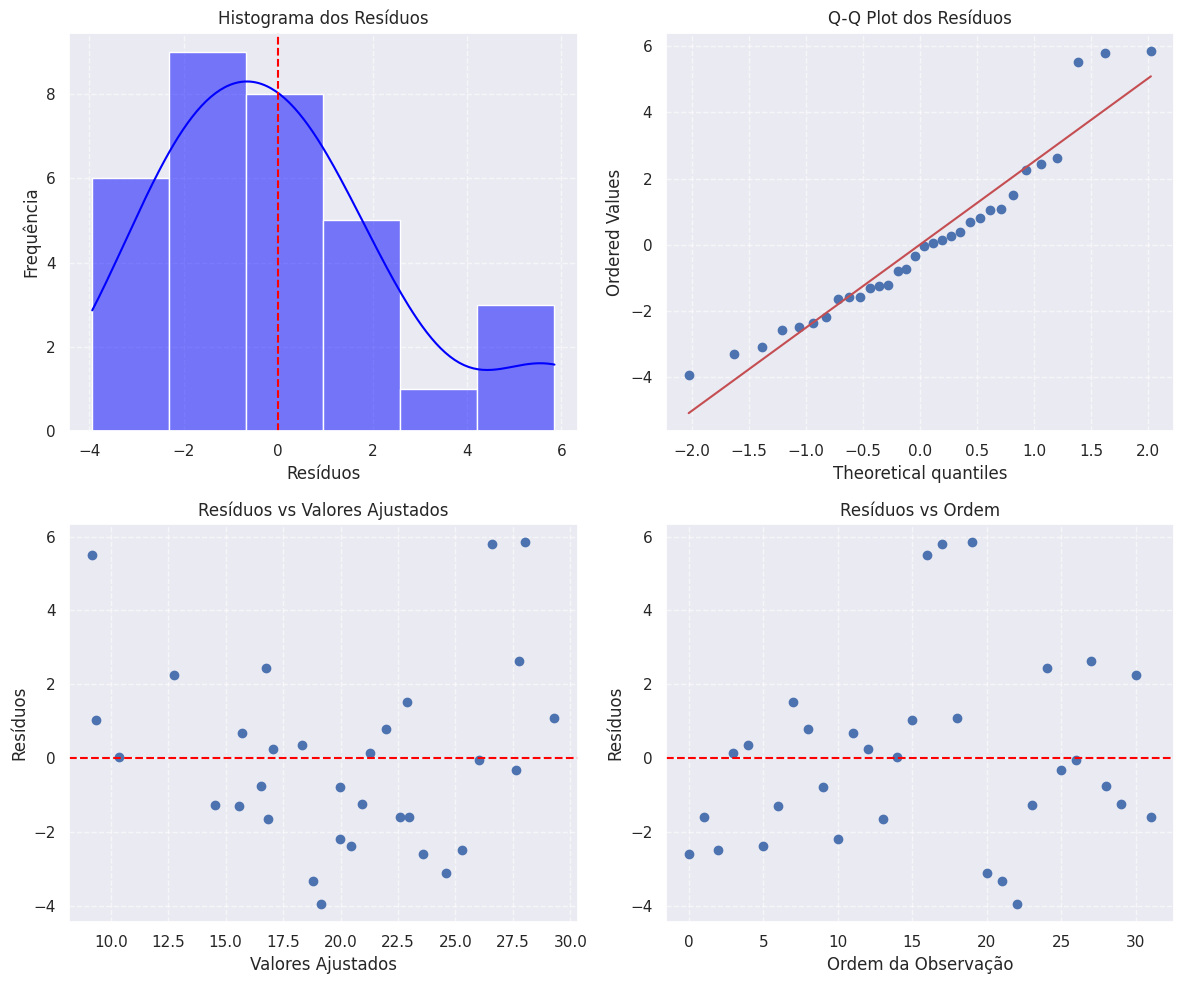

1. TESTE DE NORMALIDADE (Shapiro-Wilk):
Estatística: 0.9279, Valor p: 0.0343
Conclusão: Os resíduos não seguem uma distribuição normal (p < 0.05)

2. TESTE DE HOMOSCEDASTICIDADE (Breusch-Pagan):
Estatística: 0.8807, Valor p: 0.6438
Conclusão: Os resíduos não apresentam heteroscedasticidade (p > 0.05)

3. TESTE DE AUTOCORRELAÇÃO (Durbin-Watson):
Estatística: 1.3624
Conclusão: Possível autocorrelação positiva dos resíduos (DW < 1.5)


In [46]:
# DIAGNÓSTICO DE RESÍDUOS DO MODELO FINAL
print("="*60)
print("DIAGNÓSTICO DE RESÍDUOS DO MODELO FINAL")
print("="*60)

# Obter os resíduos do modelo final
residuos_final = modelo_final.resid
plt.figure(figsize=(12, 10))

# 1. Histograma dos resíduos
plt.subplot(2, 2, 1)
sns.histplot(residuos_final, kde=True, color='blue')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Histograma dos Resíduos', fontsize=12)
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Q-Q plot para verificar normalidade
plt.subplot(2, 2, 2)
stats.probplot(residuos_final, dist='norm', plot=plt)
plt.title('Q-Q Plot dos Resíduos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Resíduos vs Valores ajustados
plt.subplot(2, 2, 3)
plt.scatter(modelo_final.fittedvalues, residuos_final)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Resíduos vs Valores Ajustados', fontsize=12)
plt.xlabel('Valores Ajustados')
plt.ylabel('Resíduos')
plt.grid(True, linestyle='--', alpha=0.6)

# 4. Resíduos vs Ordem de observação
plt.subplot(2, 2, 4)
plt.scatter(range(len(residuos_final)), residuos_final)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Resíduos vs Ordem', fontsize=12)
plt.xlabel('Ordem da Observação')
plt.ylabel('Resíduos')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 1. Teste de normalidade
stat, pval = stats.shapiro(residuos_final)
print("1. TESTE DE NORMALIDADE (Shapiro-Wilk):")
print(f"Estatística: {stat:.4f}, Valor p: {pval:.4f}")
print(f"Conclusão: Os resíduos {'não ' if pval < 0.05 else ''}seguem uma distribuição normal (p {'<' if pval < 0.05 else '>'} 0.05)\n")

# 2. Teste de heteroscedasticidade
bp_test = het_breuschpagan(residuos_final, modelo_final.model.exog)
print("2. TESTE DE HOMOSCEDASTICIDADE (Breusch-Pagan):")
print(f"Estatística: {bp_test[0]:.4f}, Valor p: {bp_test[1]:.4f}")
print(f"Conclusão: Os resíduos {'apresentam' if bp_test[1] < 0.05 else 'não apresentam'} heteroscedasticidade (p {'<' if bp_test[1] < 0.05 else '>'} 0.05)\n")

# 3. Teste de autocorrelação
dw = durbin_watson(residuos_final)
print("3. TESTE DE AUTOCORRELAÇÃO (Durbin-Watson):")
print(f"Estatística: {dw:.4f}")
if dw < 1.5:
    print("Conclusão: Possível autocorrelação positiva dos resíduos (DW < 1.5)")
elif dw > 2.5:
    print("Conclusão: Possível autocorrelação negativa dos resíduos (DW > 2.5)")
else:
    print("Conclusão: Não há evidência forte de autocorrelação (1.5 < DW < 2.5)")

VISUALIZAÇÃO DO AJUSTE DO MODELO FINAL


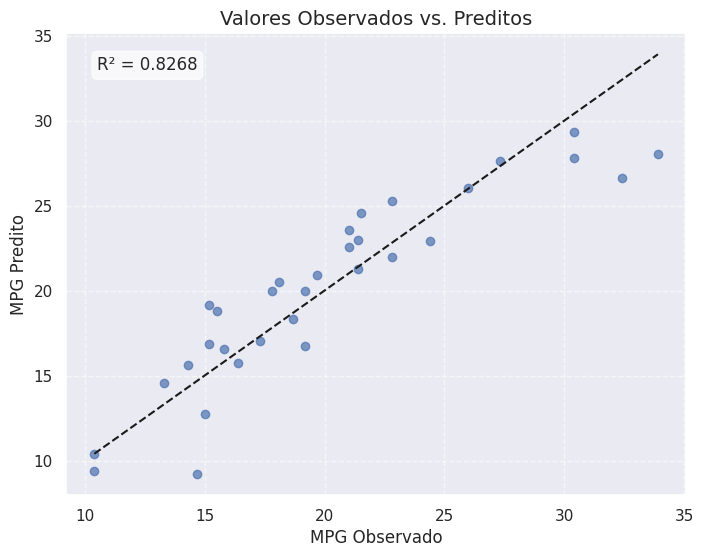

MÉTRICAS DE ERRO DO MODELO FINAL:
----------------------------------------
• Erro Absoluto Médio (MAE): 1.9015
  → Em média, o modelo erra por 1.9015 unidades de mpg.

• Erro Quadrático Médio (MSE): 6.0952

• Raiz do Erro Quadrático Médio (RMSE): 2.4689
  → Esta é uma estimativa do erro típico do modelo, na mesma unidade de mpg.


In [47]:
# VISUALIZAÇÃO DO AJUSTE DO MODELO FINAL
print("="*60)
print("VISUALIZAÇÃO DO AJUSTE DO MODELO FINAL")
print("="*60)

# Calcular valores preditos
y_pred = modelo_final.predict(base)

# Gráfico de valores observados vs. preditos
plt.figure(figsize=(8, 6))
plt.scatter(base['mpg'], y_pred, alpha=0.7)
plt.plot([base['mpg'].min(), base['mpg'].max()],
         [base['mpg'].min(), base['mpg'].max()], 'k--')
plt.xlabel('MPG Observado', fontsize=12)
plt.ylabel('MPG Predito', fontsize=12)
plt.title('Valores Observados vs. Preditos', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Adicionar uma legenda com o R²
plt.annotate(f'R² = {modelo_final.rsquared:.4f}',
             xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=12, ha='left', va='top',
             bbox=dict(boxstyle='round', fc='white', alpha=0.7))
plt.show()

mae = np.mean(np.abs(base['mpg'] - y_pred))
mse = np.mean((base['mpg'] - y_pred)**2)
rmse = np.sqrt(mse)

print("MÉTRICAS DE ERRO DO MODELO FINAL:")
print("-"*40)
print(f"• Erro Absoluto Médio (MAE): {mae:.4f}")
print(f"  → Em média, o modelo erra por {mae:.4f} unidades de mpg.")
print(f"\n• Erro Quadrático Médio (MSE): {mse:.4f}")
print(f"\n• Raiz do Erro Quadrático Médio (RMSE): {rmse:.4f}")
print(f"  → Esta é uma estimativa do erro típico do modelo, na mesma unidade de mpg.")

VISUALIZAÇÃO DOS EFEITOS PARCIAIS DAS VARIÁVEIS


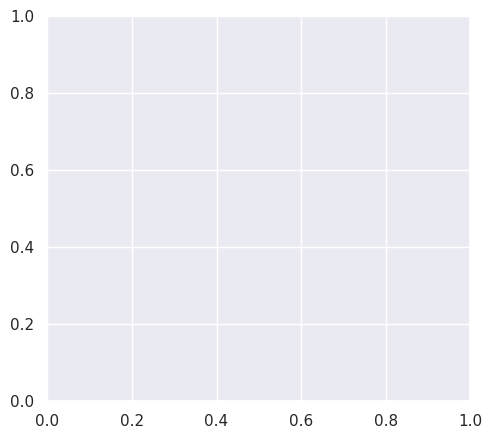

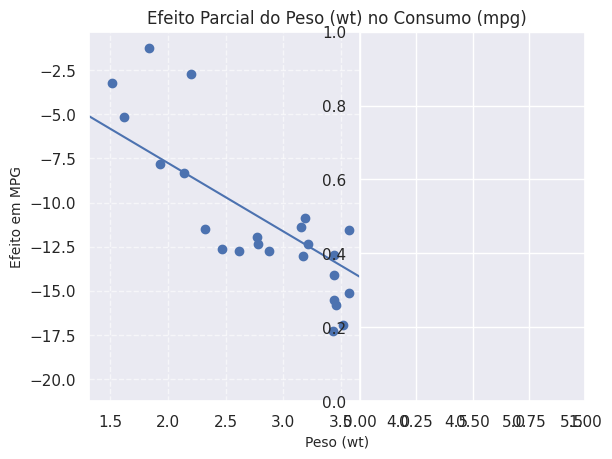

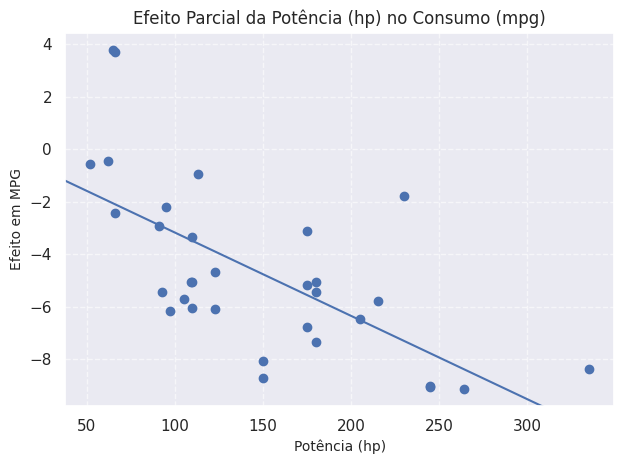

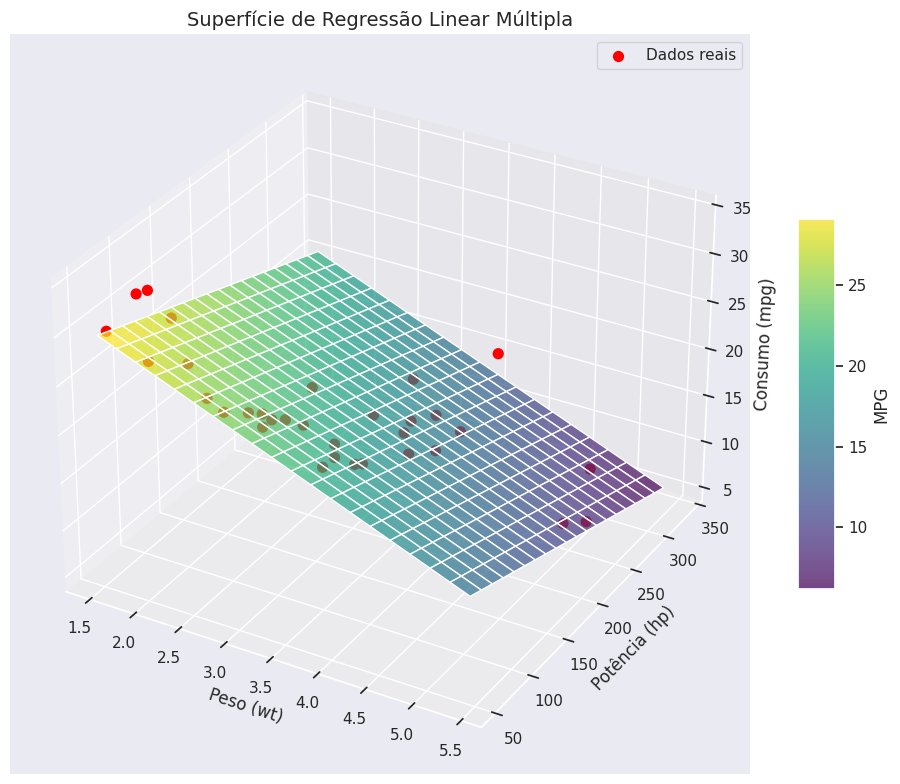

In [48]:
# VISUALIZAÇÃO DOS EFEITOS PARCIAIS DAS VARIÁVEIS
print("="*60)
print("VISUALIZAÇÃO DOS EFEITOS PARCIAIS DAS VARIÁVEIS")
print("="*60)

plt.figure(figsize=(12, 5))

# Efeito parcial do peso (wt)
plt.subplot(1, 2, 1)
plot_ccpr(modelo_final, 'wt')
plt.title('Efeito Parcial do Peso (wt) no Consumo (mpg)', fontsize=12)
plt.xlabel('Peso (wt)', fontsize=10)
plt.ylabel('Efeito em MPG', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

# Efeito parcial da potência (hp)
plt.subplot(1, 2, 2)
plot_ccpr(modelo_final, 'hp')
plt.title('Efeito Parcial da Potência (hp) no Consumo (mpg)', fontsize=12)
plt.xlabel('Potência (hp)', fontsize=10)
plt.ylabel('Efeito em MPG', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# Criar grade de valores para wt e hp
wt_range = np.linspace(base['wt'].min(), base['wt'].max(), 20)
hp_range = np.linspace(base['hp'].min(), base['hp'].max(), 20)
wt_grid, hp_grid = np.meshgrid(wt_range, hp_range)

# Calcular os valores previstos de mpg para cada par (wt, hp)
mpg_grid = modelo_final.params['Intercept'] + \
           modelo_final.params['wt'] * wt_grid + \
           modelo_final.params['hp'] * hp_grid

# Criar o gráfico 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plotar a superfície de regressão
surface = ax.plot_surface(wt_grid, hp_grid, mpg_grid, cmap='viridis', alpha=0.7)

# Adicionar os pontos de dados reais
ax.scatter(base['wt'], base['hp'], base['mpg'], color='red', s=50, alpha=1, label='Dados reais')

# Configurar o gráfico
ax.set_xlabel('Peso (wt)', fontsize=12)
ax.set_ylabel('Potência (hp)', fontsize=12)
ax.set_zlabel('Consumo (mpg)', fontsize=12)
ax.set_title('Superfície de Regressão Linear Múltipla', fontsize=14)

# Adicionar barra de cores
fig.colorbar(surface, ax=ax, shrink=0.5, aspect=10, label='MPG')

plt.legend()
plt.tight_layout()
plt.show()

EXEMPLO DE PREVISÃO COM O MODELO FINAL
Previsões de consumo para diferentes tipos de carros:
-------------------------------------------------------------------------------------
Descrição                 | Peso (wt)  | Potência (hp)   | MPG Previsto   
-------------------------------------------------------------------------------------
Carro leve e econômico    | 2.2        | 90              | 25.84          
Carro médio padrão        | 3.0        | 150             | 20.83          
Carro médio potente       | 3.8        | 200             | 16.14          
Carro pesado e potente    | 4.5        | 250             | 11.83          
-------------------------------------------------------------------------------------


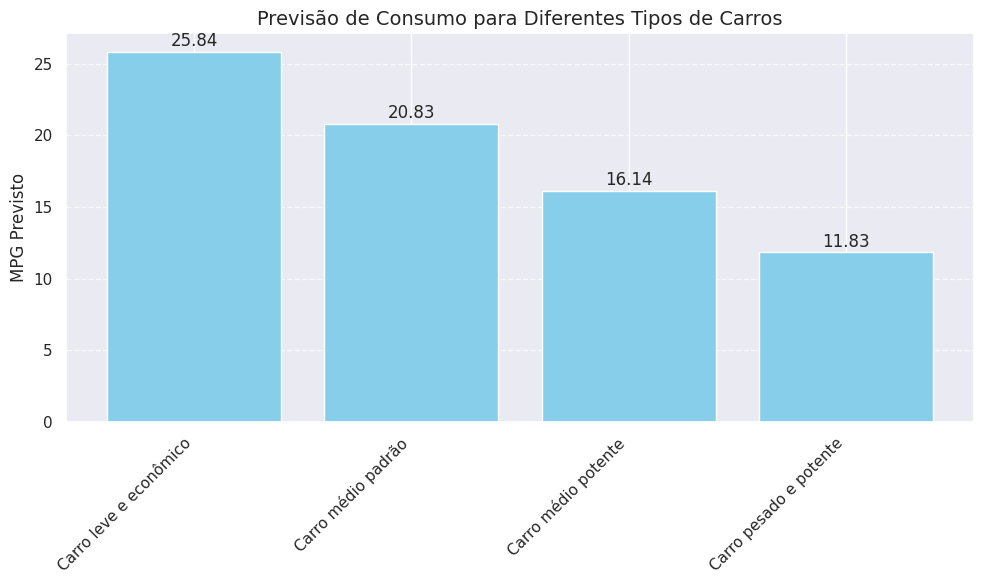

In [49]:
# EXEMPLO DE PREVISÃO COM O MODELO FINAL
print("="*60)
print("EXEMPLO DE PREVISÃO COM O MODELO FINAL")
print("="*60)

# Criar alguns exemplos de carros para previsão
novos_carros = pd.DataFrame({
    'wt': [2.2, 3.0, 3.8, 4.5],
    'hp': [90, 150, 200, 250]
})

# Adicionar descrições para cada carro
novos_carros['descrição'] = [
    'Carro leve e econômico',
    'Carro médio padrão',
    'Carro médio potente',
    'Carro pesado e potente'
]

# Fazer previsões com o modelo
novos_carros['mpg_previsto'] = modelo_final.predict(novos_carros)

# Mostrar os resultados em uma tabela formatada
print("Previsões de consumo para diferentes tipos de carros:")
print("-"*85)
print(f"{'Descrição':<25} | {'Peso (wt)':<10} | {'Potência (hp)':<15} | {'MPG Previsto':<15}")
print("-"*85)
for i, carro in novos_carros.iterrows():
    print(f"{carro['descrição']:<25} | {carro['wt']:<10.1f} | {carro['hp']:<15.0f} | {carro['mpg_previsto']:<15.2f}")
print("-"*85)

# Criar um gráfico visual das previsões
plt.figure(figsize=(10, 6))
bars = plt.bar(novos_carros['descrição'], novos_carros['mpg_previsto'], color='skyblue')
plt.ylabel('MPG Previsto', fontsize=12)
plt.title('Previsão de Consumo para Diferentes Tipos de Carros', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores nas barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [50]:
# DOCUMENTAÇÃO E CONCLUSÕES FINAIS
print("="*60)
print("CONCLUSÕES FINAIS DA ANÁLISE DE REGRESSÃO LINEAR")
print("="*60)

print("1. RESUMO DO MODELO FINAL:")
print("-"*40)
print(f"• Modelo selecionado: mpg ~ wt + hp")
print(f"• R² = {modelo_final.rsquared:.4f} - O modelo explica {modelo_final.rsquared*100:.1f}% da variância em mpg")
print(f"• R² Ajustado = {modelo_final.rsquared_adj:.4f}")
print(f"• AIC = {modelo_final.aic:.2f}")
print(f"• RMSE = {rmse:.4f}")

print("\n2. EQUAÇÃO DO MODELO:")
print("-"*40)
print(f"mpg = {modelo_final.params['Intercept']:.2f} + ({modelo_final.params['wt']:.2f} × wt) + ({modelo_final.params['hp']:.4f} × hp)")

print("\n3. INTERPRETAÇÃO DOS COEFICIENTES:")
print("-"*40)
print(f"• Peso (wt): {modelo_final.params['wt']:.2f}")
print(f"  → Mantendo a potência constante, cada aumento de 1000 libras no peso")
print(f"    está associado a uma diminuição de {abs(modelo_final.params['wt']):.2f} mpg.")
print(f"• Potência (hp): {modelo_final.params['hp']:.4f}")
print(f"  → Mantendo o peso constante, cada aumento de 10 HP na potência")
print(f"    está associado a uma diminuição de {abs(modelo_final.params['hp'])*10:.2f} mpg.")

print("\n4. VERIFICAÇÃO DOS PRESSUPOSTOS:")
print("-"*40)
print(f"• Normalidade: {'Não atendido' if pval < 0.05 else 'Atendido'} (p = {pval:.4f})")
print(f"• Homoscedasticidade: {'Não atendido' if bp_test[1] < 0.05 else 'Atendido'} (p = {bp_test[1]:.4f})")
print(f"• Independência: {'Possível autocorrelação' if dw < 1.5 or dw > 2.5 else 'Atendido'} (DW = {dw:.4f})")

print("\n5. LIMITAÇÕES DO MODELO:")
print("-"*40)
if pval < 0.05:
    print("• A não-normalidade dos resíduos pode afetar a validade dos intervalos de confiança e testes de hipótese.")
    print("  → Possíveis soluções: transformações nas variáveis ou métodos robustos.")
if dw < 1.5:
    print("• Possível autocorrelação nos resíduos.")
    print("  → Isso pode ocorrer se houver alguma ordem temporal nos dados.")
print("• O modelo assume relações lineares entre as variáveis, o que pode não ser totalmente preciso.")
print("• O conjunto de dados é relativamente pequeno (n=32), o que limita a generalização.")

print("\n6. APLICAÇÕES PRÁTICAS:")
print("-"*40)
print("• Este modelo pode ser usado para estimar o consumo de combustível (mpg) de carros,")
print("  conhecendo apenas seu peso e potência.")
print("• Fabricantes podem usar essa relação para desenvolvimento de novos veículos,")
print("  estimando o impacto de mudanças no peso ou potência sobre a economia de combustível.")
print("• Consumidores podem usar o modelo para comparar veículos com base em características técnicas.")

print("\n7. PRÓXIMOS PASSOS:")
print("-"*40)
print("• Considerar transformações (como log) nas variáveis para melhorar a normalidade dos resíduos.")
print("• Explorar possíveis relações não-lineares entre as variáveis.")
print("• Validar o modelo com um conjunto de dados de teste independente.")
print("• Investigar outras variáveis que possam melhorar o poder preditivo do modelo.")

CONCLUSÕES FINAIS DA ANÁLISE DE REGRESSÃO LINEAR
1. RESUMO DO MODELO FINAL:
----------------------------------------
• Modelo selecionado: mpg ~ wt + hp
• R² = 0.8268 - O modelo explica 82.7% da variância em mpg
• R² Ajustado = 0.8148
• AIC = 154.65
• RMSE = 2.4689

2. EQUAÇÃO DO MODELO:
----------------------------------------
mpg = 37.23 + (-3.88 × wt) + (-0.0318 × hp)

3. INTERPRETAÇÃO DOS COEFICIENTES:
----------------------------------------
• Peso (wt): -3.88
  → Mantendo a potência constante, cada aumento de 1000 libras no peso
    está associado a uma diminuição de 3.88 mpg.
• Potência (hp): -0.0318
  → Mantendo o peso constante, cada aumento de 10 HP na potência
    está associado a uma diminuição de 0.32 mpg.

4. VERIFICAÇÃO DOS PRESSUPOSTOS:
----------------------------------------
• Normalidade: Não atendido (p = 0.0343)
• Homoscedasticidade: Atendido (p = 0.6438)
• Independência: Possível autocorrelação (DW = 1.3624)

5. LIMITAÇÕES DO MODELO:
------------------------------